In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("/content/Cleaned_Customer_Churn.csv")

In [ ]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.shape

(7043, 50)

In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [ ]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [ ]:
total_customers = df.shape[0]
print("Total Customers:", total_customers)

Total Customers: 7043


In [ ]:
churned_customers = df[df['Churn Label'] == 'Yes'].shape[0]
print("Churned Customers:", churned_customers)

Churned Customers: 1869


In [ ]:
churn_rate = (churned_customers / total_customers) * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.54%


In [ ]:
avg_monthly = df['Monthly Charge'].mean()
print(f"Average Monthly Charges: {avg_monthly:.2f}")

Average Monthly Charges: 64.76


In [ ]:
avg_tenure = df['Tenure in Months'].mean()
print(f"Average Tenure: {avg_tenure:.2f} months")

Average Tenure: 32.39 months


In [ ]:
avg_total = df['Total Charges'].mean()
print(f"Average Total Charges: {avg_total:.2f}")

Average Total Charges: 2280.38


## Univariate Analysis

/tmp/ipykernel_494/3060282977.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn Label', data=df, palette='viridis')


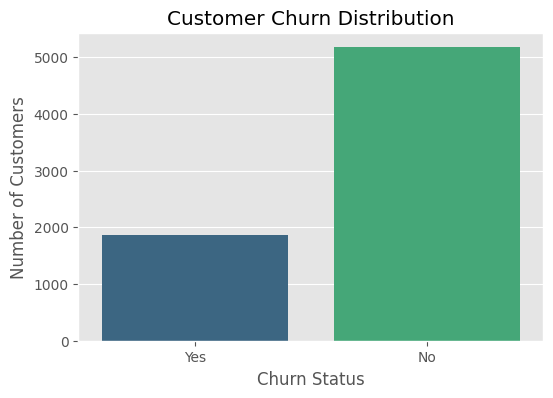

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Churn Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn Label', data=df, palette='viridis')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Churn Distribution
This plot shows the number of customers who churned ('Yes') versus those who did not ('No'). A significant portion of customers have churned, which highlights the importance of this analysis.

/tmp/ipykernel_494/3504087565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


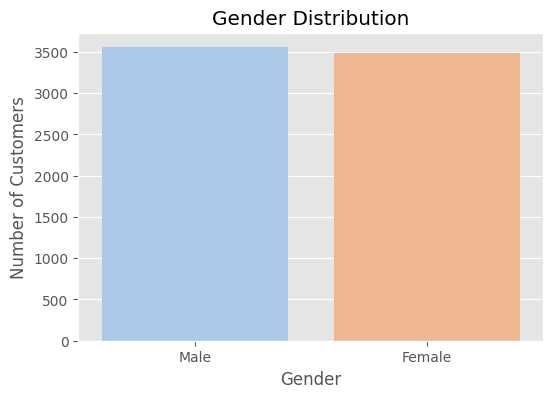

In [ ]:
# 2. Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Gender Distribution
The distribution of customers by gender appears to be relatively balanced, indicating no significant imbalance that might bias other analyses.

/tmp/ipykernel_494/2968117577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Contract', data=df, palette='deep')


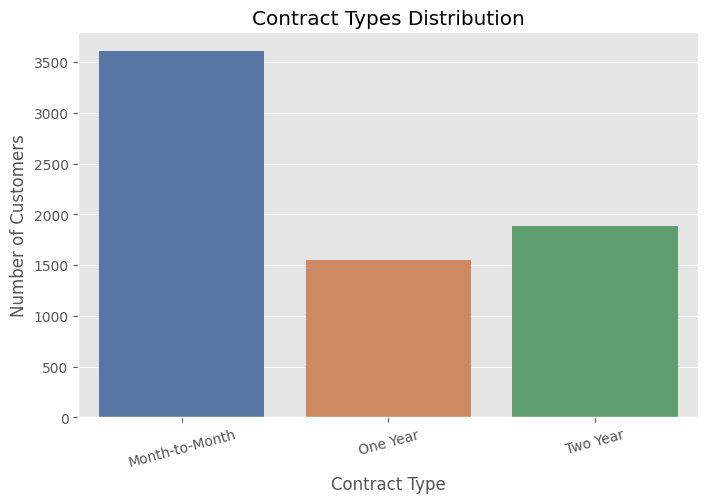

In [ ]:
# 3. Contract Type Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, palette='deep')
plt.xticks(rotation=15)
plt.title('Contract Types Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Contract Type
Most customers are on a 'Month-to-Month' contract, which often correlates with higher churn rates due to less commitment. Fewer customers are on 'One Year' or 'Two Year' contracts.

/tmp/ipykernel_494/826439727.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Internet Service', data=df, palette='flare')


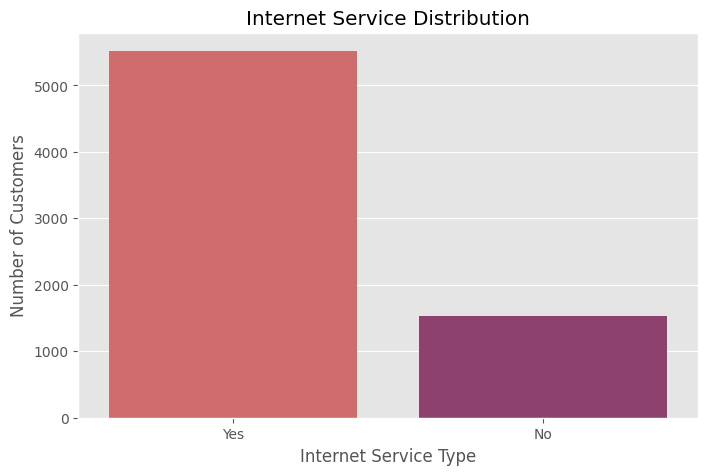

In [ ]:
# 4. Internet Service Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Internet Service', data=df, palette='flare')
plt.title('Internet Service Distribution')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Internet Service
The majority of customers utilize 'Fiber Optic' internet service, followed by 'DSL'. A notable portion of customers also have 'No' internet service, which could be a factor in their overall engagement.

/tmp/ipykernel_494/631761343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Payment Method', data=df, palette='crest')


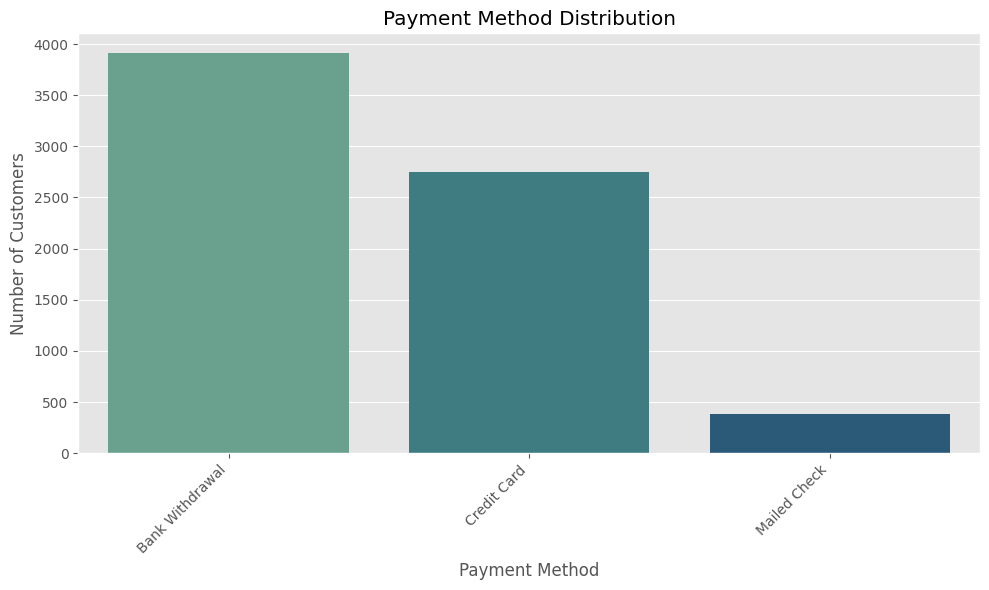

In [ ]:
# 5. Payment Method Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Payment Method', data=df, palette='crest')
plt.xticks(rotation=45, ha='right')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

### Insight: Payment Method
'Electronic check' is the most common payment method, followed by 'Mailed check' and 'Bank transfer (automatic)'. This distribution could be insightful when analyzing churn, as certain payment methods might be associated with higher or lower churn rates.

## Numerical Analysis

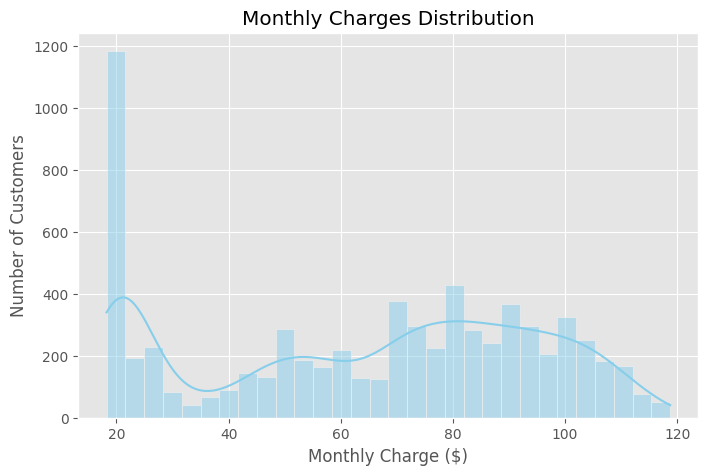

In [ ]:
# Monthly Charges Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Monthly Charge'], bins=30, kde=True, color='skyblue')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charge ($)')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Monthly Charges Distribution
The distribution of monthly charges shows a bimodal shape, with peaks at lower charges and higher charges. This might indicate different customer segments based on their service packages.

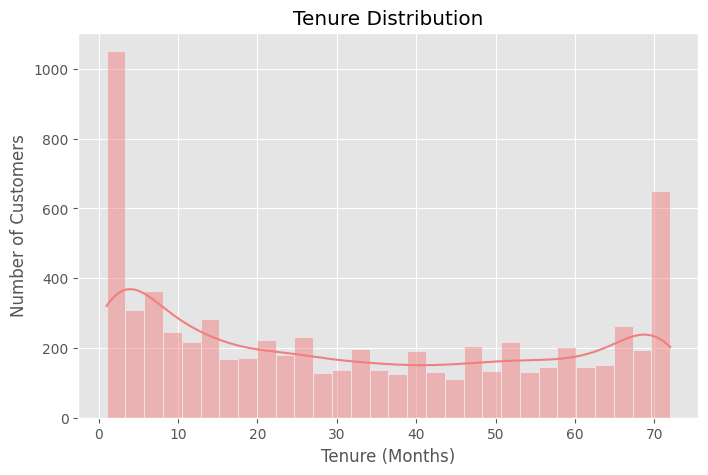

In [ ]:
# Tenure Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Tenure in Months'], bins=30, kde=True, color='lightcoral')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Tenure Distribution
The tenure distribution is skewed towards shorter tenures (many new customers) and longer tenures (loyal customers), with fewer customers in the middle range. This pattern is common in subscription-based services.

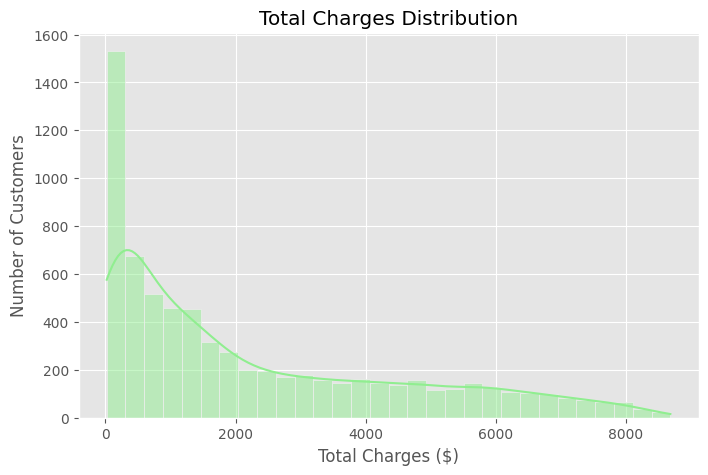

In [ ]:
# Total Charges Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Charges'], bins=30, kde=True, color='lightgreen')
plt.title('Total Charges Distribution')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

### Insight: Total Charges Distribution
Most customers have lower total charges, which is expected given the high number of new customers. The distribution shows a long tail towards higher total charges, indicating a segment of long-term, high-value customers.

## Bivariate Analysis

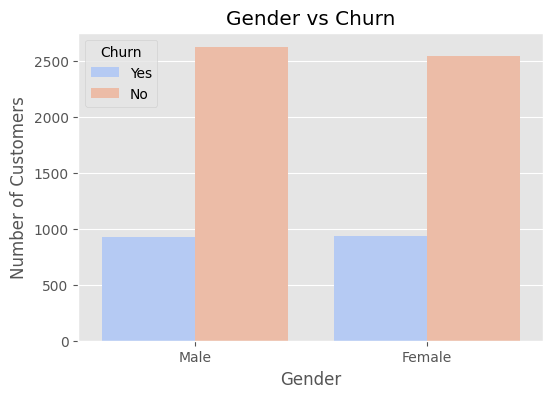

In [ ]:
# Churn vs Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Churn Label', data=df, palette='coolwarm')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Gender
This plot shows that churn rates are fairly similar across genders, indicating that gender alone might not be a strong predictor of churn. Both male and female customers churn at comparable rates.

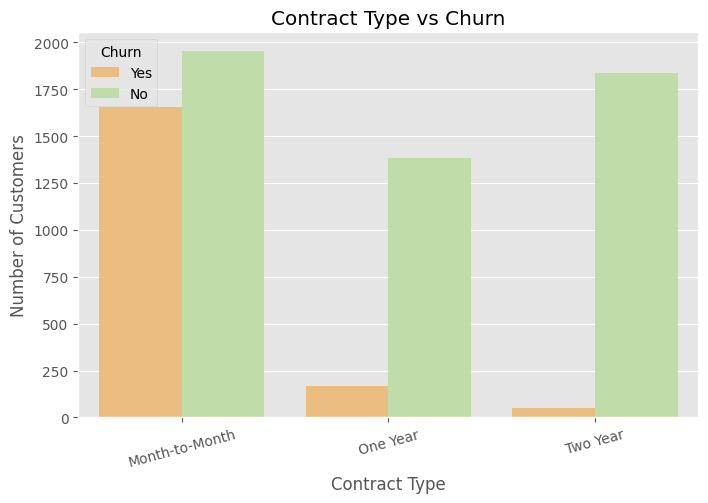

In [ ]:
# Churn vs Contract
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn Label', data=df, palette='Spectral')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Contract
Customers on 'Month-to-Month' contracts have a significantly higher churn rate compared to those on 'One Year' or 'Two Year' contracts. This suggests that longer contract terms reduce churn.

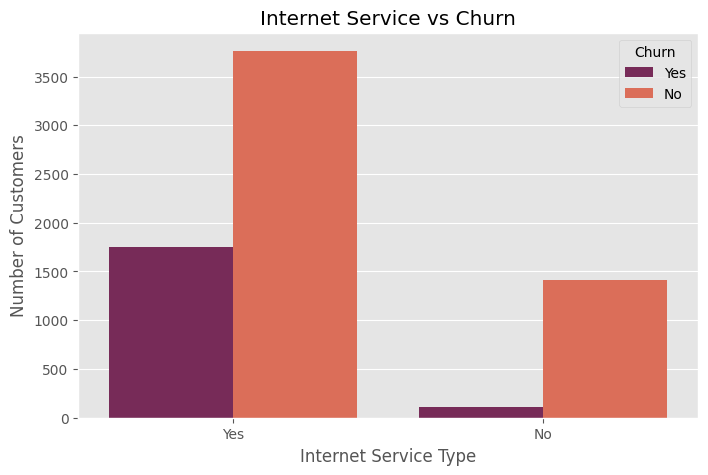

In [ ]:
# Churn vs Internet Service
plt.figure(figsize=(8, 5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df, palette='rocket')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Internet Service
Customers with 'Fiber Optic' internet service show a higher propensity to churn compared to those with 'DSL'. Customers with 'No' internet service have a very low churn rate, possibly due to simpler service offerings.

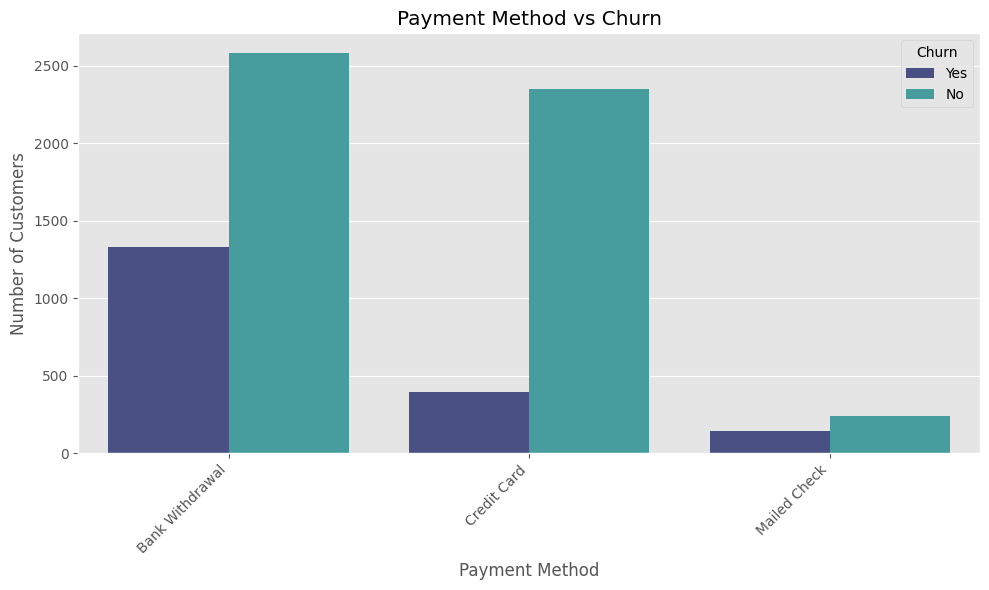

In [ ]:
# Churn vs Payment Method
plt.figure(figsize=(10, 6))
sns.countplot(x='Payment Method', hue='Churn Label', data=df, palette='mako')
plt.xticks(rotation=45, ha='right')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Insight: Churn vs Payment Method
'Electronic check' payment method is associated with a much higher churn rate than other payment methods. This could indicate issues or dissatisfaction specific to this payment option or the customer segment using it.

/tmp/ipykernel_494/3786256207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Monthly Charge', data=df, palette='viridis')


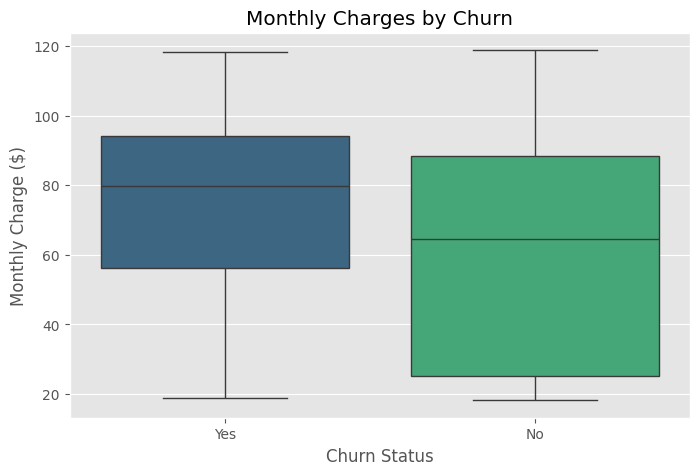

In [ ]:
# Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df, palette='viridis')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charge ($)')
plt.show()

### Insight: Monthly Charges vs Churn
Customers who churn have noticeably higher monthly charges on average compared to those who do not churn. This suggests that higher costs may be a significant factor in customer dissatisfaction and churn.

/tmp/ipykernel_494/624462692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Tenure in Months', data=df, palette='plasma')


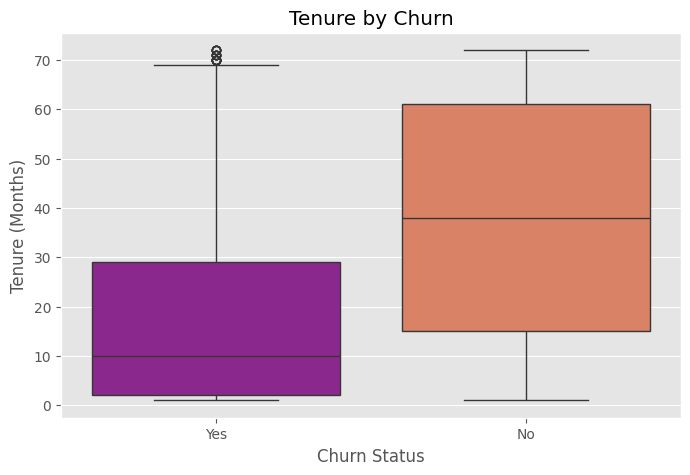

In [ ]:
# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Tenure in Months', data=df, palette='plasma')
plt.title('Tenure by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

### Insight: Tenure vs Churn
Customers who churn tend to have significantly shorter tenures than those who do not churn. This highlights the importance of retaining new customers, as churn is more prevalent in the early stages of a customer's lifecycle.

/tmp/ipykernel_494/2227601934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Total Charges', data=df, palette='magma')


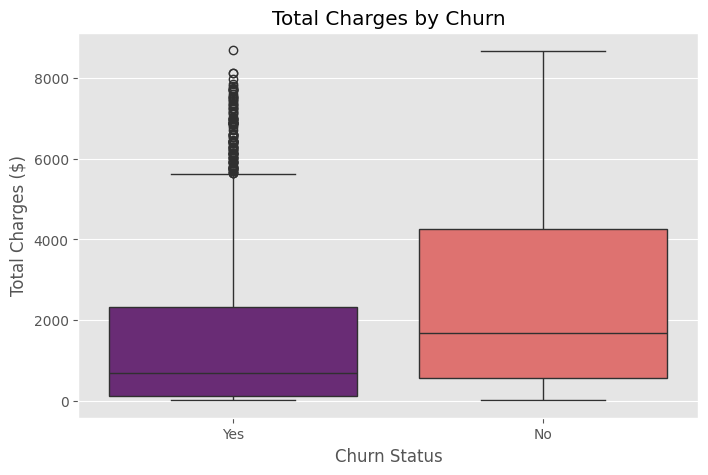

In [ ]:
# Total Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Total Charges', data=df, palette='magma')
plt.title('Total Charges by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Total Charges ($)')
plt.show()

### Insight: Total Charges vs Churn
Customers who churn generally have lower total charges. This aligns with the observation that churned customers have shorter tenures, resulting in lower accumulated charges over time compared to loyal customers.

## Correlation Analysis

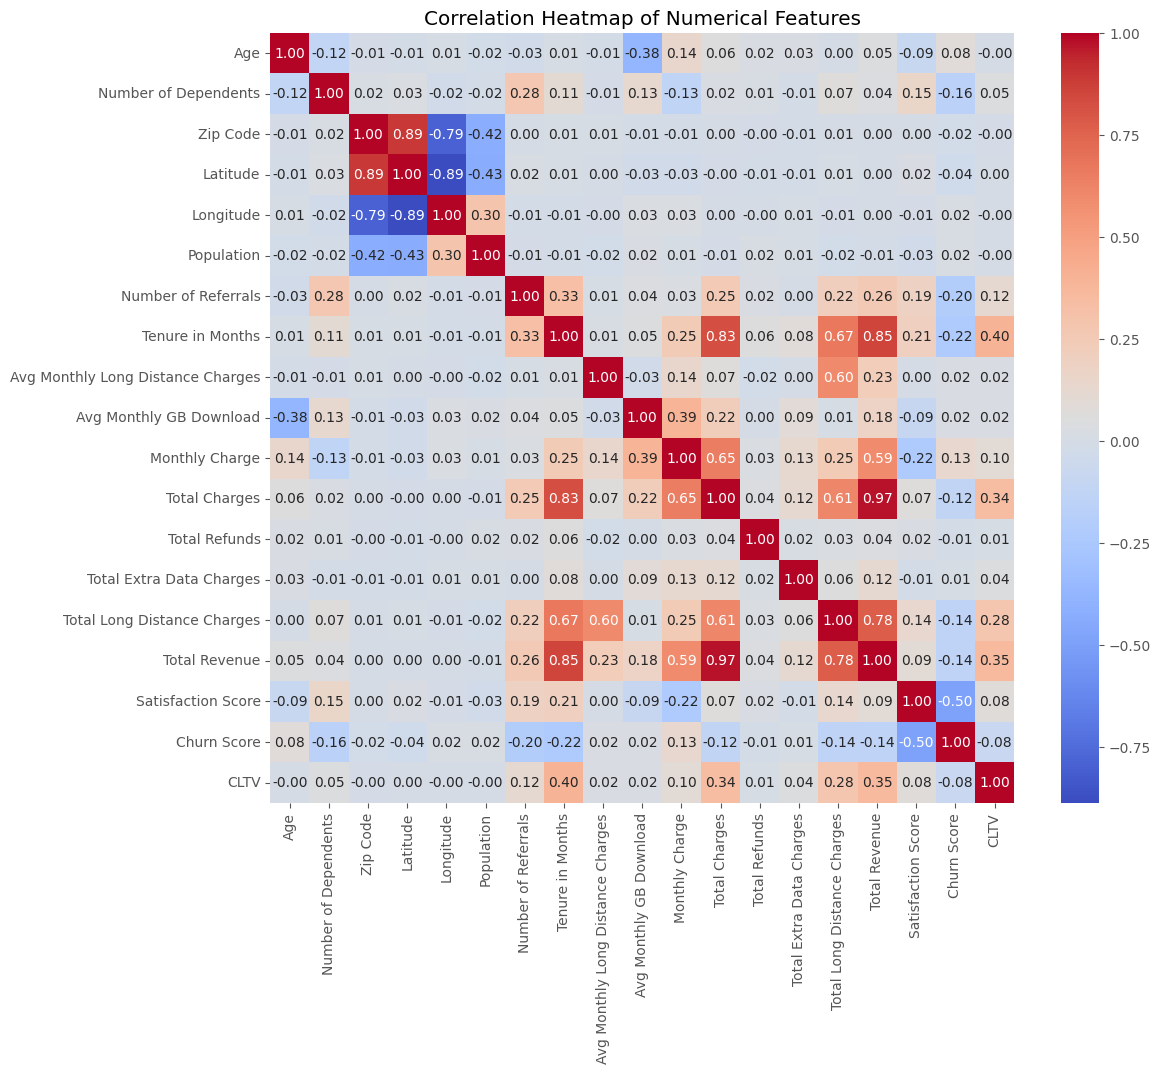

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insight: Correlation Heatmap
The correlation heatmap reveals relationships between numerical features. Strong positive correlations are observed between 'Tenure in Months', 'Total Charges', and 'Total Revenue'. 'Monthly Charge' also shows a positive correlation with 'Total Charges' and 'Total Revenue'. This indicates that longer-term customers with higher monthly charges contribute more to total revenue and total charges. Understanding these relationships can help identify key drivers of customer value.

## Bivariate Analysis

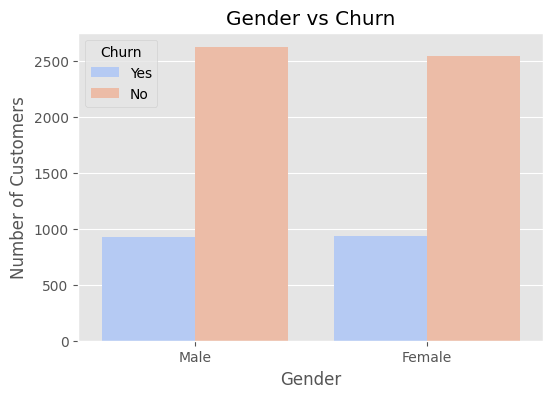

In [ ]:
# Churn vs Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', hue='Churn Label', data=df, palette='coolwarm')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Gender
This plot shows that churn rates are fairly similar across genders, indicating that gender alone might not be a strong predictor of churn. Both male and female customers churn at comparable rates.

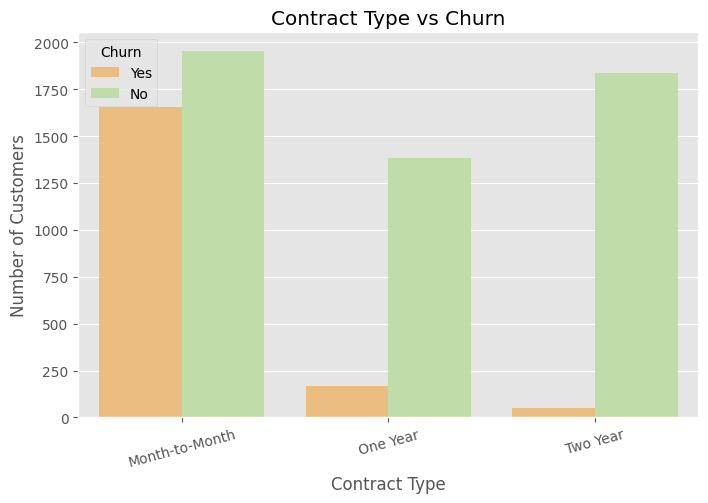

In [ ]:
# Churn vs Contract
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn Label', data=df, palette='Spectral')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Contract
Customers on 'Month-to-Month' contracts have a significantly higher churn rate compared to those on 'One Year' or 'Two Year' contracts. This suggests that longer contract terms reduce churn.

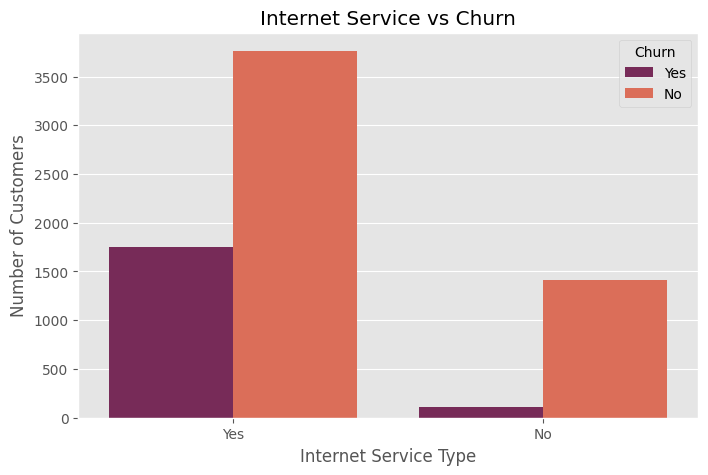

In [ ]:
# Churn vs Internet Service
plt.figure(figsize=(8, 5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df, palette='rocket')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Insight: Churn vs Internet Service
Customers with 'Fiber Optic' internet service show a higher propensity to churn compared to those with 'DSL'. Customers with 'No' internet service have a very low churn rate, possibly due to simpler service offerings.

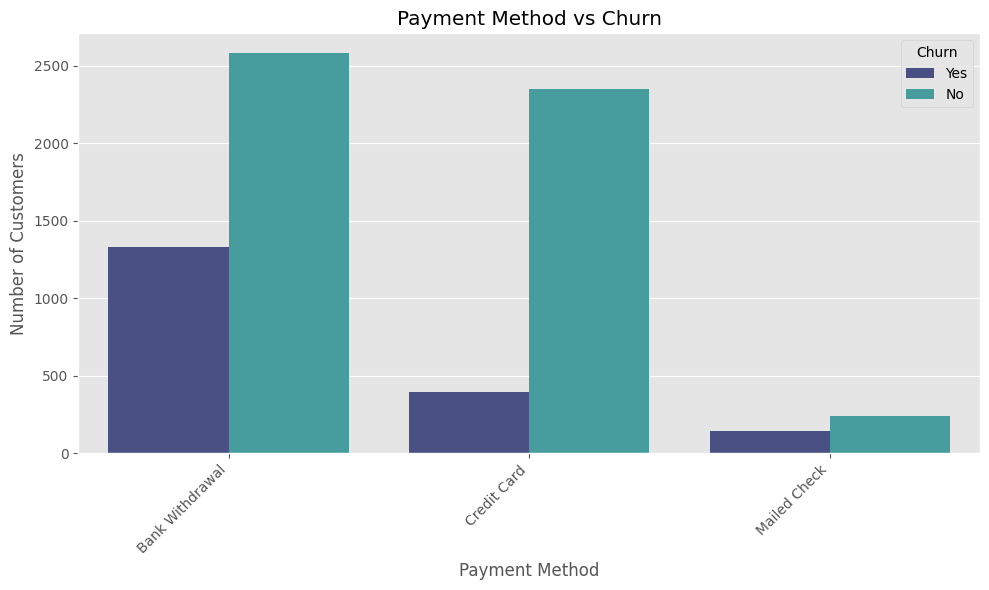

In [ ]:
# Churn vs Payment Method
plt.figure(figsize=(10, 6))
sns.countplot(x='Payment Method', hue='Churn Label', data=df, palette='mako')
plt.xticks(rotation=45, ha='right')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Insight: Churn vs Payment Method
'Electronic check' payment method is associated with a much higher churn rate than other payment methods. This could indicate issues or dissatisfaction specific to this payment option or the customer segment using it.

/tmp/ipykernel_494/3786256207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Monthly Charge', data=df, palette='viridis')


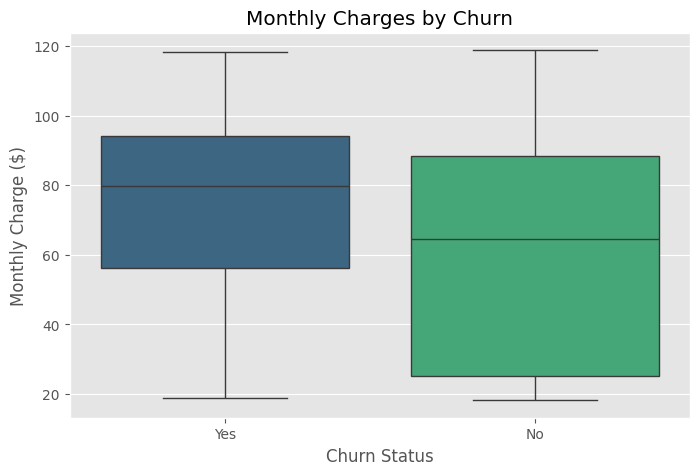

In [ ]:
# Monthly Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Monthly Charge', data=df, palette='viridis')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charge ($)')
plt.show()

### Insight: Monthly Charges vs Churn
Customers who churn have noticeably higher monthly charges on average compared to those who do not churn. This suggests that higher costs may be a significant factor in customer dissatisfaction and churn.

/tmp/ipykernel_494/624462692.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Tenure in Months', data=df, palette='plasma')


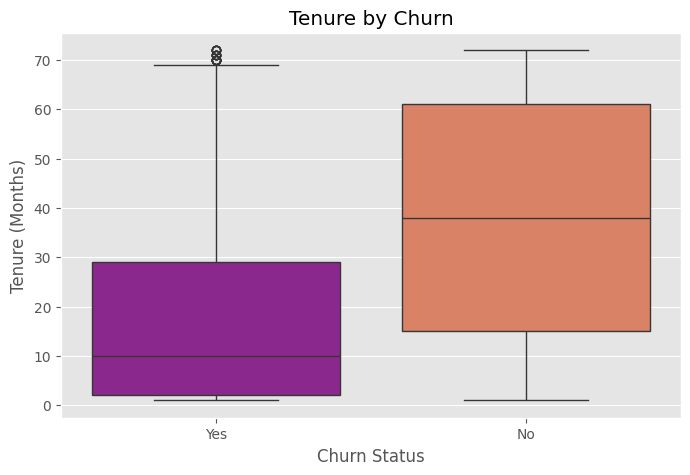

In [ ]:
# Tenure vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Tenure in Months', data=df, palette='plasma')
plt.title('Tenure by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

### Insight: Tenure vs Churn
Customers who churn tend to have significantly shorter tenures than those who do not churn. This highlights the importance of retaining new customers, as churn is more prevalent in the early stages of a customer's lifecycle.

/tmp/ipykernel_494/2227601934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn Label', y='Total Charges', data=df, palette='magma')


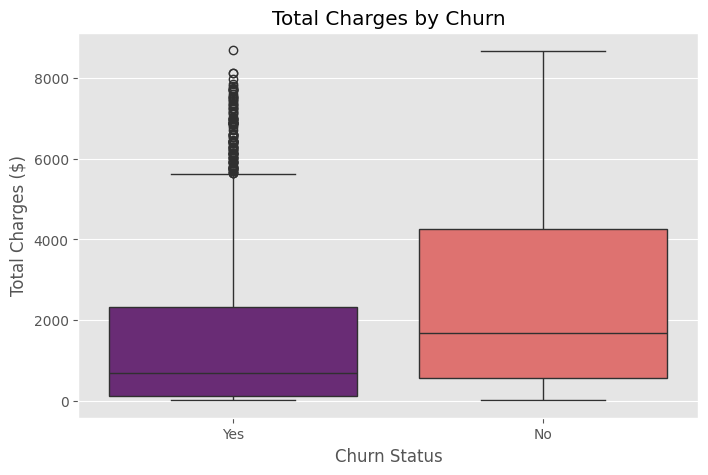

In [ ]:
# Total Charges vs Churn
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn Label', y='Total Charges', data=df, palette='magma')
plt.title('Total Charges by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Total Charges ($)')
plt.show()

### Insight: Total Charges vs Churn
Customers who churn generally have lower total charges. This aligns with the observation that churned customers have shorter tenures, resulting in lower accumulated charges over time compared to loyal customers.

## Correlation Analysis

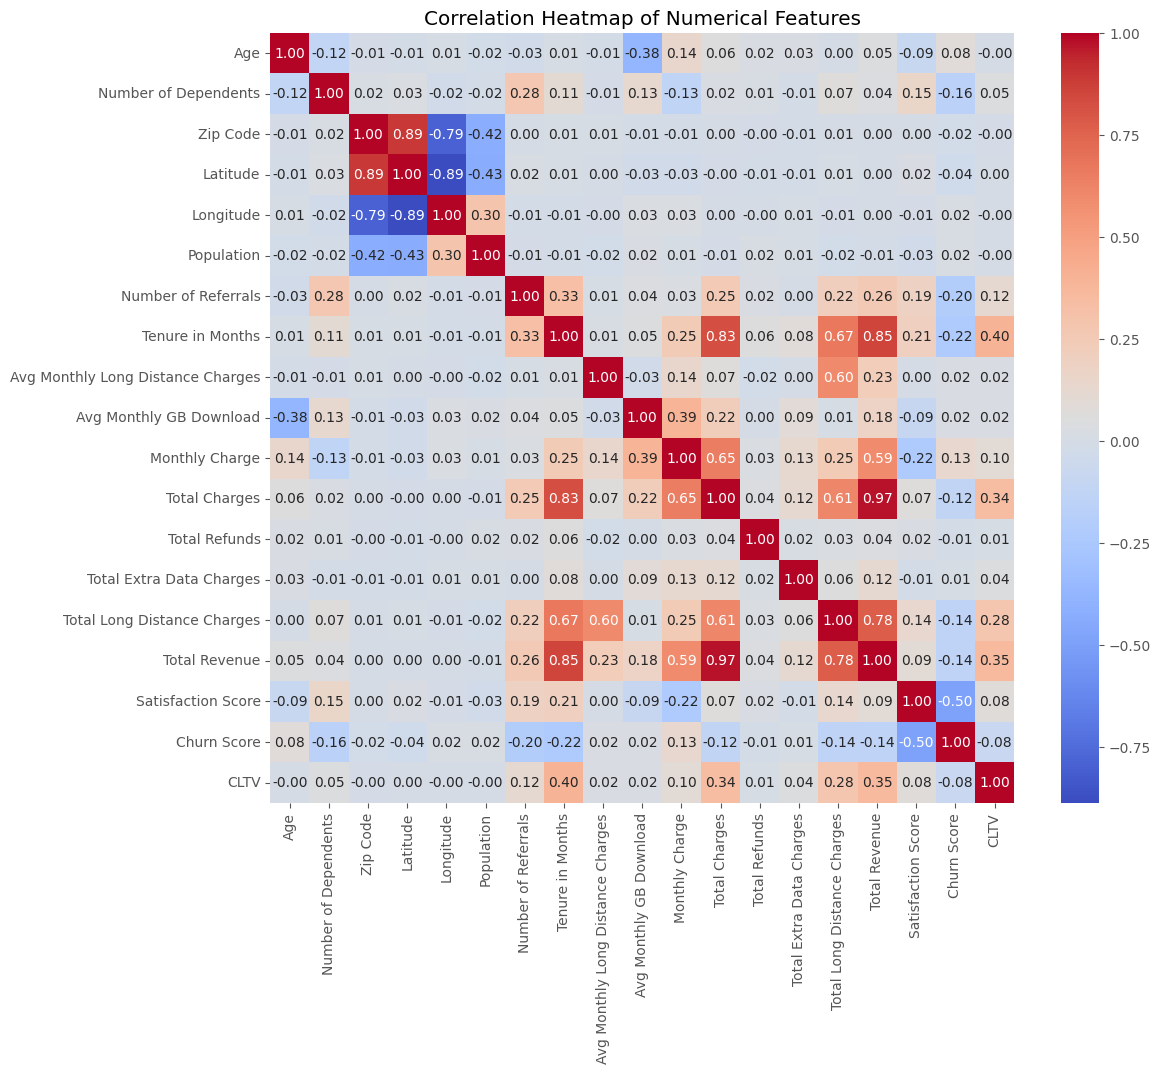

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insight: Correlation Heatmap
The correlation heatmap reveals relationships between numerical features. Strong positive correlations are observed between 'Tenure in Months', 'Total Charges', and 'Total Revenue'. 'Monthly Charge' also shows a positive correlation with 'Total Charges' and 'Total Revenue'. This indicates that longer-term customers with higher monthly charges contribute more to total revenue and total charges. Understanding these relationships can help identify key drivers of customer value.